Iter    0 | Loss 9.230955 | Train RMSE 3.032914 | Test RMSE 3.041647 | Best Test RMSE 3.041647 at iter 0
Iter   25 | Loss 8.453655 | Train RMSE 2.902426 | Test RMSE 2.937646 | Best Test RMSE 2.937646 at iter 25
Iter   50 | Loss 7.750445 | Train RMSE 2.779183 | Test RMSE 2.840239 | Best Test RMSE 2.840239 at iter 50
Iter   75 | Loss 7.119198 | Train RMSE 2.663707 | Test RMSE 2.750005 | Best Test RMSE 2.750005 at iter 75
Iter  100 | Loss 6.552141 | Train RMSE 2.555518 | Test RMSE 2.665846 | Best Test RMSE 2.665846 at iter 100
Iter  125 | Loss 6.041156 | Train RMSE 2.453930 | Test RMSE 2.586725 | Best Test RMSE 2.586725 at iter 125
Iter  150 | Loss 5.579054 | Train RMSE 2.358282 | Test RMSE 2.512128 | Best Test RMSE 2.512128 at iter 150
Iter  175 | Loss 5.159832 | Train RMSE 2.268011 | Test RMSE 2.441695 | Best Test RMSE 2.441695 at iter 175
Iter  200 | Loss 4.778531 | Train RMSE 2.182658 | Test RMSE 2.375086 | Best Test RMSE 2.375086 at iter 200
Iter  225 | Loss 4.430986 | Train RMSE 2.1

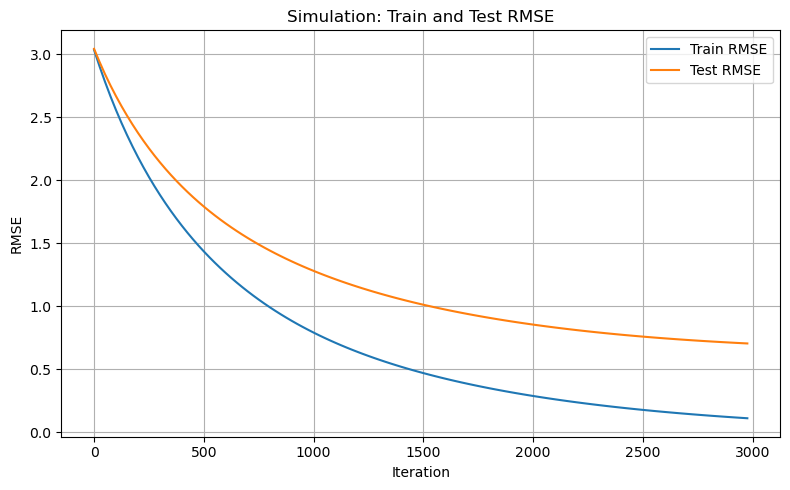

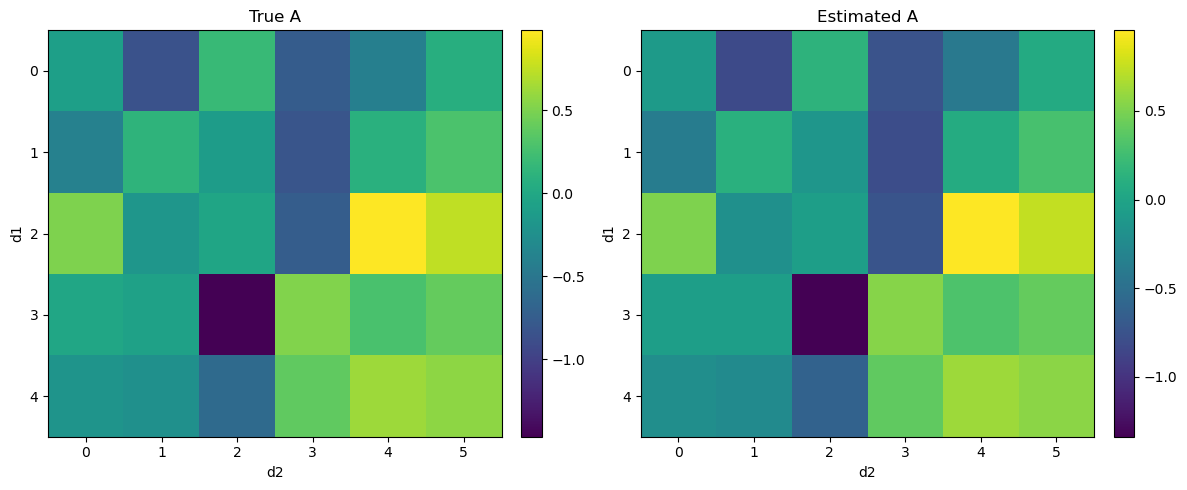

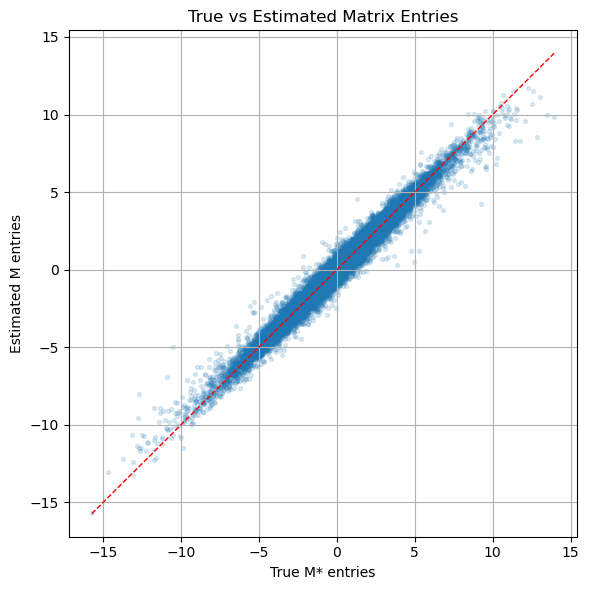

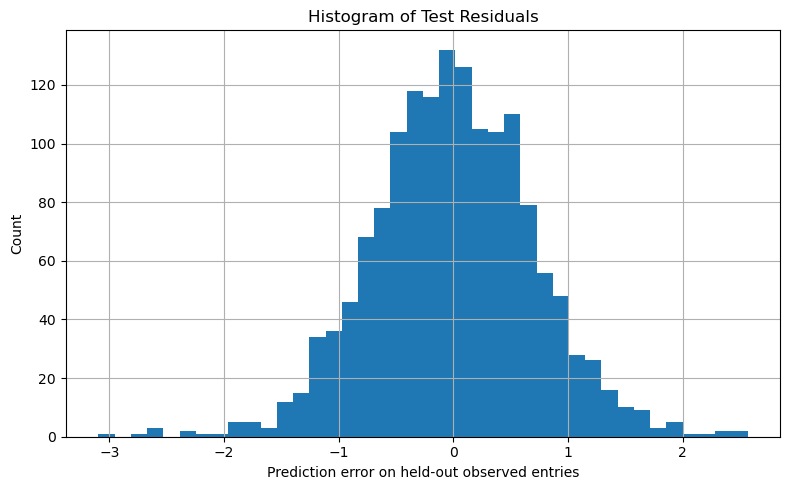


Residual mean: -0.002749776
Residual std : 0.7054519

Component Frobenius norms
||WAZ^T||_F true / hat : 414.0043 / 403.3910
||WB^T||_F  true / hat : 44.8882 / 56.9466
||CZ^T||_F  true / hat : 49.2548 / 59.6987
||L||_F     true / hat : 27.5248 / 37.2282


In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Full simulation script for
# M* = W A Z^T + W B^T + C Z^T + L
# where L lies in the orthogonal complement of W and Z:
#     L = P_W_perp L P_Z_perp
# ============================================================


# 0. Reproducibility
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cpu")


# 1. Simulation configuration
cfg = {
    "n1": 120,          # number of rows
    "n2": 160,          # number of columns
    "d1": 5,            # row-side covariate dimension
    "d2": 6,            # col-side covariate dimension
    "r_true": 2,        # only used to generate a low-rank true L if desired
    "obs_prob": 0.4,    # observation probability
    "sigma": 0.5,       # noise std
    "scale_A": 0.5,
    "scale_B": 0.15,
    "scale_C": 0.15,
    "scale_X": 0.4,     # used only for generating true low-rank L_star = X_star Y_star^T
    "scale_Y": 0.4,
    "lr": 1e-3,
    "max_iter": 3000,
    "eval_every": 25,
    "patience": 12,
    "lam_A": 1e-4,
    "lam_B": 5e-4,
    "lam_C": 5e-4,
    "lam_L": 5e-4,
}


# 2. Helper functions
def column_standardize_np(A: np.ndarray) -> np.ndarray:
    A = A.copy()
    A -= A.mean(axis=0, keepdims=True)
    std = A.std(axis=0, keepdims=True)
    std[std < 1e-10] = 1.0
    A /= std
    return A.astype(np.float32)

def compute_projection_perp(A_t: torch.Tensor) -> torch.Tensor:
    Q, _ = torch.linalg.qr(A_t, mode="reduced")
    I = torch.eye(A_t.shape[0], dtype=A_t.dtype, device=A_t.device)
    return I - Q @ Q.T

def rmse_on_entries(M_hat, user_idx, item_idx, target):
    pred = M_hat[user_idx, item_idx]
    return torch.sqrt(torch.mean((pred - target) ** 2))

def relative_fro_error(A_hat, A_true):
    num = torch.norm(A_hat - A_true, p="fro")
    den = torch.norm(A_true, p="fro")
    return (num / den).item()


# 3. Generate covariates and true matrices
n1 = cfg["n1"]
n2 = cfg["n2"]
d1 = cfg["d1"]
d2 = cfg["d2"]
r_true = cfg["r_true"]

# W and Z
W = column_standardize_np(np.random.randn(n1, d1))
Z = column_standardize_np(np.random.randn(n2, d2))

W_t = torch.tensor(W, dtype=torch.float32, device=device)
Z_t = torch.tensor(Z, dtype=torch.float32, device=device)

P_W_perp = compute_projection_perp(W_t)
P_Z_perp = compute_projection_perp(Z_t)

# True parameters
A_star = cfg["scale_A"] * np.random.randn(d1, d2).astype(np.float32)
B_star = cfg["scale_B"] * np.random.randn(n2, d1).astype(np.float32)
C_star = cfg["scale_C"] * np.random.randn(n1, d2).astype(np.float32)

# Generate a true low-rank latent term first, then collapse it into L_star
X_star = cfg["scale_X"] * np.random.randn(n1, r_true).astype(np.float32)
Y_star = cfg["scale_Y"] * np.random.randn(n2, r_true).astype(np.float32)

A_star_t = torch.tensor(A_star, dtype=torch.float32, device=device)
B_star_t = torch.tensor(B_star, dtype=torch.float32, device=device)
C_star_t = torch.tensor(C_star, dtype=torch.float32, device=device)
X_star_t = torch.tensor(X_star, dtype=torch.float32, device=device)
Y_star_t = torch.tensor(Y_star, dtype=torch.float32, device=device)

with torch.no_grad():
    # Project B and C to enforce identifiability
    B_star_t = P_Z_perp @ B_star_t
    C_star_t = P_W_perp @ C_star_t

    # Build true latent matrix L_star from X_star Y_star^T, then project both sides
    L_star_t = X_star_t @ Y_star_t.T
    L_star_t = P_W_perp @ L_star_t @ P_Z_perp

    # True components
    term_A_star = W_t @ A_star_t @ Z_t.T
    term_B_star = W_t @ B_star_t.T
    term_C_star = C_star_t @ Z_t.T
    term_L_star = L_star_t

    M_star_t = term_A_star + term_B_star + term_C_star + term_L_star

M_star = M_star_t.cpu().numpy()


# 4. Generate noisy observations
sigma = cfg["sigma"]
E = sigma * np.random.randn(n1, n2).astype(np.float32)
Y_full = M_star + E

Omega = (np.random.rand(n1, n2) < cfg["obs_prob"])

# ensure each row/column has at least one observed entry
for i in range(n1):
    if Omega[i].sum() == 0:
        j = np.random.randint(n2)
        Omega[i, j] = True
for j in range(n2):
    if Omega[:, j].sum() == 0:
        i = np.random.randint(n1)
        Omega[i, j] = True

obs_idx = np.argwhere(Omega)
perm = np.random.permutation(len(obs_idx))
obs_idx = obs_idx[perm]

n_obs = len(obs_idx)
n_train = int(0.8 * n_obs)

train_pairs = obs_idx[:n_train]
test_pairs = obs_idx[n_train:]

train_user_idx = torch.tensor(train_pairs[:, 0], dtype=torch.long, device=device)
train_item_idx = torch.tensor(train_pairs[:, 1], dtype=torch.long, device=device)
test_user_idx = torch.tensor(test_pairs[:, 0], dtype=torch.long, device=device)
test_item_idx = torch.tensor(test_pairs[:, 1], dtype=torch.long, device=device)

Y_full_t = torch.tensor(Y_full, dtype=torch.float32, device=device)
train_rating = Y_full_t[train_user_idx, train_item_idx]
test_rating = Y_full_t[test_user_idx, test_item_idx]


# 5. Model
class ProjectedGMC(nn.Module):
    def __init__(self, n1, n2, d1, d2):
        super().__init__()
        self.A = nn.Parameter(0.01 * torch.randn(d1, d2))
        self.B = nn.Parameter(0.01 * torch.randn(n2, d1))
        self.C = nn.Parameter(0.01 * torch.randn(n1, d2))
        self.L = nn.Parameter(0.01 * torch.randn(n1, n2))

    def forward(self, W, Z):
        return (
            W @ self.A @ Z.T
            + W @ self.B.T
            + self.C @ Z.T
            + self.L
        )

    @torch.no_grad()
    def project_parameters(self, P_W_perp, P_Z_perp):
        self.B.data = P_Z_perp @ self.B.data
        self.C.data = P_W_perp @ self.C.data
        self.L.data = P_W_perp @ self.L.data @ P_Z_perp


# 6. Fitting the model
model = ProjectedGMC(n1, n2, d1, d2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])

model.project_parameters(P_W_perp, P_Z_perp)

best_state = None
best_test_rmse = float("inf")
best_iter = -1
patience_counter = 0

iter_hist = []
loss_hist = []
train_hist = []
test_hist = []

for t in range(cfg["max_iter"]):
    model.train()
    optimizer.zero_grad()

    M_hat = model(W_t, Z_t)
    pred_train = M_hat[train_user_idx, train_item_idx]

    mse_loss = torch.mean((pred_train - train_rating) ** 2)
    reg_loss = (
        cfg["lam_A"] * torch.sum(model.A ** 2)
        + cfg["lam_B"] * torch.sum(model.B ** 2)
        + cfg["lam_C"] * torch.sum(model.C ** 2)
        + cfg["lam_L"] * torch.sum(model.L ** 2)
    ) / n_train

    loss = mse_loss + reg_loss
    loss.backward()
    optimizer.step()
    model.project_parameters(P_W_perp, P_Z_perp)

    if t % cfg["eval_every"] == 0:
        with torch.no_grad():
            M_eval = model(W_t, Z_t)
            train_rmse = rmse_on_entries(M_eval, train_user_idx, train_item_idx, train_rating).item()
            test_rmse = rmse_on_entries(M_eval, test_user_idx, test_item_idx, test_rating).item()

        iter_hist.append(t)
        loss_hist.append(loss.item())
        train_hist.append(train_rmse)
        test_hist.append(test_rmse)

        if test_rmse < best_test_rmse:
            best_test_rmse = test_rmse
            best_iter = t
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        print(
            f"Iter {t:4d} | Loss {loss.item():.6f} | "
            f"Train RMSE {train_rmse:.6f} | Test RMSE {test_rmse:.6f} | "
            f"Best Test RMSE {best_test_rmse:.6f} at iter {best_iter}"
        )

        if patience_counter >= cfg["patience"]:
            print(f"Early stopping at iter {t}.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print(f"\nLoaded best model from iter {best_iter} with best test RMSE {best_test_rmse:.6f}")


# 7. Extract estimates and recovery quantities
with torch.no_grad():
    A_hat_t = model.A.detach()
    B_hat_t = model.B.detach()
    C_hat_t = model.C.detach()
    L_hat_t = model.L.detach()

    term_A_hat = W_t @ A_hat_t @ Z_t.T
    term_B_hat = W_t @ B_hat_t.T
    term_C_hat = C_hat_t @ Z_t.T
    term_L_hat = L_hat_t
    M_hat_t = term_A_hat + term_B_hat + term_C_hat + term_L_hat

# Recovery metrics
err_M = relative_fro_error(M_hat_t, M_star_t)
err_A = relative_fro_error(A_hat_t, A_star_t)

true_BC_term = term_B_star + term_C_star
hat_BC_term = term_B_hat + term_C_hat
err_BC_effect = relative_fro_error(hat_BC_term, true_BC_term)

err_L_effect = relative_fro_error(term_L_hat, term_L_star)

print("\n================ Recovery Metrics ================")
print(f"Relative Frobenius error of M         : {err_M:.6f}")
print(f"Relative Frobenius error of A         : {err_A:.6f}")
print(f"Relative Frobenius error of B/C effect: {err_BC_effect:.6f}")
print(f"Relative Frobenius error of L effect  : {err_L_effect:.6f}")
print("==================================================")


# 8. Compare train/test RMSE
with torch.no_grad():
    train_rmse_best = rmse_on_entries(M_hat_t, train_user_idx, train_item_idx, train_rating).item()
    test_rmse_best = rmse_on_entries(M_hat_t, test_user_idx, test_item_idx, test_rating).item()

print("\n================ Prediction Metrics ===============")
print(f"Best train RMSE on noisy observed train entries : {train_rmse_best:.6f}")
print(f"Best test  RMSE on noisy observed test entries  : {test_rmse_best:.6f}")
print("==================================================")


# 9. Export fitted parameter arrays
A_hat = A_hat_t.cpu().numpy()
B_hat = B_hat_t.cpu().numpy()
C_hat = C_hat_t.cpu().numpy()
L_hat = L_hat_t.cpu().numpy()

A_true = A_star_t.cpu().numpy()
B_true = B_star_t.cpu().numpy()
C_true = C_star_t.cpu().numpy()
L_true = L_star_t.cpu().numpy()


# 10. Results summary
summary_df = pd.DataFrame(
    {
        "Metric": [
            "Best test RMSE",
            "Relative error M",
            "Relative error A",
            "Relative error BC effect",
            "Relative error L effect",
        ],
        "Value": [
            best_test_rmse,
            err_M,
            err_A,
            err_BC_effect,
            err_L_effect,
        ],
    }
)
print("\nSummary table:")
print(summary_df)


# 11. Visualization block

# (a) Train/test RMSE vs iteration
plt.figure(figsize=(8, 5))
plt.plot(iter_hist, train_hist, label="Train RMSE")
plt.plot(iter_hist, test_hist, label="Test RMSE")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("Simulation: Train and Test RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# (b) Heatmap of true A and estimated A
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(A_true, aspect="auto")
axes[0].set_title("True A")
axes[0].set_xlabel("d2")
axes[0].set_ylabel("d1")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(A_hat, aspect="auto")
axes[1].set_title("Estimated A")
axes[1].set_xlabel("d2")
axes[1].set_ylabel("d1")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# (c) Scatter: true M* vs estimated M on all entries
M_true_flat = M_star_t.cpu().numpy().ravel()
M_hat_flat = M_hat_t.cpu().numpy().ravel()

plt.figure(figsize=(6, 6))
plt.scatter(M_true_flat, M_hat_flat, alpha=0.15, s=8)
mn = min(M_true_flat.min(), M_hat_flat.min())
mx = max(M_true_flat.max(), M_hat_flat.max())
plt.plot([mn, mx], [mn, mx], "r--", linewidth=1)
plt.xlabel("True M* entries")
plt.ylabel("Estimated M entries")
plt.title("True vs Estimated Matrix Entries")
plt.grid(True)
plt.tight_layout()
plt.show()

# (d) Histogram of test residuals
with torch.no_grad():
    pred_test = M_hat_t[test_user_idx, test_item_idx].cpu().numpy()
    true_test = test_rating.cpu().numpy()
    resid_test = pred_test - true_test

plt.figure(figsize=(8, 5))
plt.hist(resid_test, bins=40)
plt.xlabel("Prediction error on held-out observed entries")
plt.ylabel("Count")
plt.title("Histogram of Test Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nResidual mean:", resid_test.mean())
print("Residual std :", resid_test.std())


# 12. Component norm comparison
with torch.no_grad():
    print("\nComponent Frobenius norms")
    print(f"||WAZ^T||_F true / hat : {torch.norm(term_A_star).item():.4f} / {torch.norm(term_A_hat).item():.4f}")
    print(f"||WB^T||_F  true / hat : {torch.norm(term_B_star).item():.4f} / {torch.norm(term_B_hat).item():.4f}")
    print(f"||CZ^T||_F  true / hat : {torch.norm(term_C_star).item():.4f} / {torch.norm(term_C_hat).item():.4f}")
    print(f"||L||_F     true / hat : {torch.norm(term_L_star).item():.4f} / {torch.norm(term_L_hat).item():.4f}")